# Some Common Derivatives — Other Power Functions

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the derivative of
$1/x$ and the general **power rule** (Week 1 — Derivatives and Optimization).

This notebook explains:

- the hyperbola $f(x) = \dfrac{1}{x} = x^{-1}$ and estimating its slope at $x = 1$ (slopes $\to -1$)
- the formal derivation $\dfrac{\Delta f}{\Delta x} = \dfrac{-1}{(x+\Delta x)x} \to -\dfrac{1}{x^2}$
- the result $\dfrac{d}{dx}x^{-1} = -x^{-2}$
- the **power rule** $\dfrac{d}{dx}x^n = n\,x^{n-1}$ holding for **any** exponent (negative, fractional)

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Some Common Derivatives — Higher Degree Polynomials*.

## 1. The function $1/x$

The function $f(x) = \dfrac{1}{x} = x^{-1}$ is a **hyperbola**. It looks more complicated,
but its derivative is computed the same way:

$$
\frac{\Delta f}{\Delta x} = \frac{(x+\Delta x)^{-1} - x^{-1}}{\Delta x},
\qquad \Delta x \to 0 .
$$

## 2. Estimating the slope at $x = 1$

At $x = 1$, $y = 1$. Shrink $\Delta x$ and watch the secant slope (note the slopes are
**negative** — the hyperbola decreases).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def f(x):
    return 1/x

x0 = 1.0
print(f"{'Δx':>10} | {'Δf':>10} | {'slope Δf/Δx':>12}")
print("-" * 38)
for dx in [1, 1/2, 1/4, 1/8, 1/16, 1/1000]:
    df = f(x0 + dx) - f(x0)
    print(f"{dx:>10.4f} | {df:>10.5f} | {df/dx:>12.5f}")
print("\n-> the slope approaches -1 = -1*(1)^(-2), the tangent slope at x=1.")

        Δx |         Δf |  slope Δf/Δx
--------------------------------------
    1.0000 |   -0.50000 |     -0.50000
    0.5000 |   -0.33333 |     -0.66667
    0.2500 |   -0.20000 |     -0.80000
    0.1250 |   -0.11111 |     -0.88889
    0.0625 |   -0.05882 |     -0.94118
    0.0010 |   -0.00100 |     -0.99900

-> the slope approaches -1 = -1*(1)^(-2), the tangent slope at x=1.


## 3. The formal derivation

$$
\frac{\Delta f}{\Delta x}
= \frac{\dfrac{1}{x+\Delta x} - \dfrac{1}{x}}{\Delta x}
= \frac{\dfrac{x - (x+\Delta x)}{(x+\Delta x)\,x}}{\Delta x}
= \frac{\dfrac{-\Delta x}{(x+\Delta x)\,x}}{\Delta x}.
$$

The $x$ and $-x$ in the numerator cancel, leaving $-\Delta x$; the $\Delta x$ then cancels:

$$
\frac{\Delta f}{\Delta x} = \frac{-1}{(x+\Delta x)\,x} \;\xrightarrow[\Delta x \to 0]{}\; -\frac{1}{x^2}.
$$

So

$$
\boxed{\;\frac{d}{dx}\,x^{-1} = -x^{-2} = -\frac{1}{x^2}.\;}
$$

In [2]:
x, dx = sp.symbols('x Delta_x')
ratio = (1/(x + dx) - 1/x) / dx
print("Δf/Δx =", sp.simplify(ratio))               # -1/(x*(x + Delta_x))
print("limit Δx->0 =", sp.limit(ratio, dx, 0))      # -1/x**2
print("SymPy d/dx (1/x) =", sp.diff(1/x, x))

Δf/Δx = -1/(x*(Delta_x + x))
limit Δx->0 = -1/x**2
SymPy d/dx (1/x) = -1/x**2


## 4. The pattern: the power rule for any exponent

Collecting what we have:

| $f(x)$ | derivative |
|---|---|
| $x^2$ | $2x^{1}$ |
| $x^3$ | $3x^{2}$ |
| $x^{-1}$ | $-1\,x^{-2}$ |

The pattern is the same in every case — the **power rule**:

$$
\boxed{\;\frac{d}{dx}\,x^n = n\,x^{\,n-1}\;}
$$

The exponent $n$ comes down as a multiplier, and the new exponent is $n-1$. It works for
**any** $n$ — positive, negative, or fractional:

- $\dfrac{d}{dx}x^{100} = 100\,x^{99}$,
- $\dfrac{d}{dx}x^{-100} = -100\,x^{-101}$,
- $\dfrac{d}{dx}x^{1/2} = \tfrac12 x^{-1/2} = \dfrac{1}{2\sqrt{x}}$.

In [3]:
x = sp.symbols('x', positive=True)
for n in [2, 3, -1, 100, -100, sp.Rational(1,2), -sp.Rational(1,2)]:
    print(f"d/dx x^({n}) = {sp.diff(x**n, x)}")

d/dx x^(2) = 2*x
d/dx x^(3) = 3*x**2
d/dx x^(-1) = -1/x**2
d/dx x^(100) = 100*x**99
d/dx x^(-100) = -100/x**101
d/dx x^(1/2) = 1/(2*sqrt(x))
d/dx x^(-1/2) = -1/(2*x**(3/2))


## 5. Visualizing

**Left:** secants on $y = 1/x$ at $x = 1$ converging to the tangent of slope $-1$.
**Right:** $f(x) = 1/x$ and its derivative $f'(x) = -1/x^2$ (always negative — $1/x$ is
decreasing where defined).

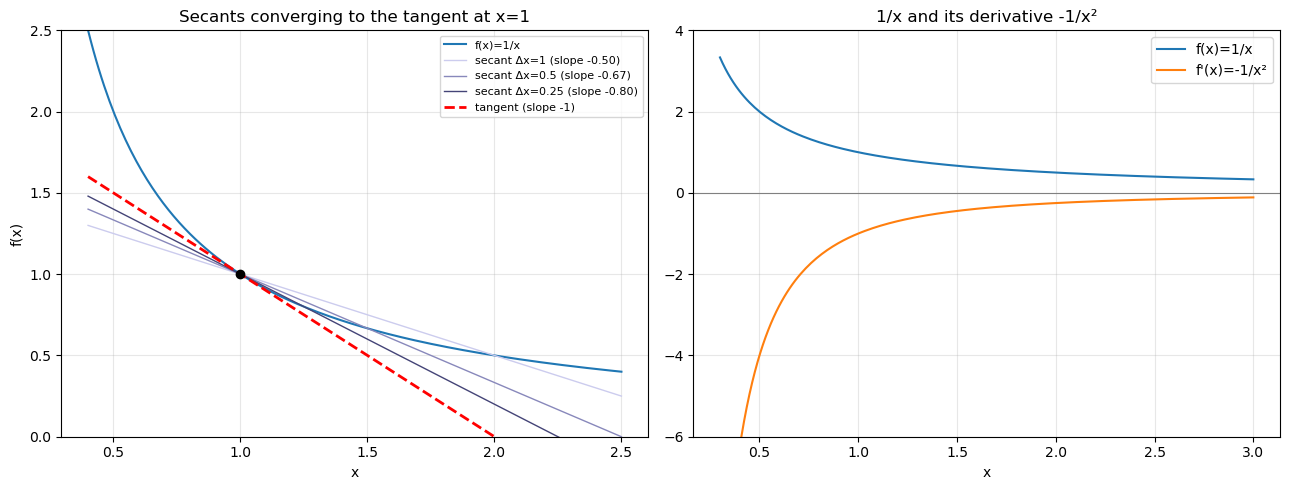

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

xs = np.linspace(0.4, 2.5, 200)
axes[0].plot(xs, 1/xs, label="f(x)=1/x")
for dx, col in zip([1, 0.5, 0.25], ["#cce", "#88b", "#447"]):
    slope = (1/(1+dx) - 1)/dx
    axes[0].plot(xs, 1 + slope*(xs-1), color=col, lw=1, label=f"secant Δx={dx} (slope {slope:.2f})")
axes[0].plot(xs, 1 + (-1)*(xs-1), "r--", lw=2, label="tangent (slope -1)")
axes[0].plot(1, 1, "ko")
axes[0].set_title("Secants converging to the tangent at x=1")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].set_ylim(0, 2.5); axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

xp = np.linspace(0.3, 3, 200)
axes[1].plot(xp, 1/xp, label="f(x)=1/x")
axes[1].plot(xp, -1/xp**2, label="f'(x)=-1/x²")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_title("1/x and its derivative -1/x²")
axes[1].set_xlabel("x"); axes[1].set_ylim(-6, 4); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Exercises

### Basic
1. What is the derivative of $f(x) = 1/x$?
2. State the power rule and note which exponents it works for.

### Intermediate
3. Estimate the slope of $1/x$ at $x = 2$ numerically and compare to $-1/x^2$.
4. Differentiate $f(x) = x^{-3}$ and $g(x) = \sqrt{x}$ using the power rule.

### Advanced
5. Using the limit definition, derive $\dfrac{d}{dx}x^{-1}$.
6. Differentiate $f(x) = \dfrac{1}{x^2} + 3\sqrt{x}$.

## 7. Solutions / Checks

In [4]:
x = sp.symbols('x', positive=True)

# 3.
dx = 1e-6
print(f"3. numeric slope of 1/x at 2: {(1/(2+dx) - 1/2)/dx:.5f}  (exact -1/4 = -0.25)")

# 4.
print("4. d/dx x^-3 =", sp.diff(x**-3, x), ";  d/dx sqrt(x) =", sp.diff(sp.sqrt(x), x))

# 5.
h = sp.symbols('h')
print("5. limit definition d/dx (1/x) =", sp.simplify(sp.limit((1/(x+h) - 1/x)/h, h, 0)))

# 6.
print("6. d/dx (1/x² + 3√x) =", sp.diff(1/x**2 + 3*sp.sqrt(x), x))

print("\n1. -1/x² (= -x^(-2)).")
print("2. d/dx xⁿ = n x^(n-1), valid for any exponent n (positive, negative, fractional).")

3. numeric slope of 1/x at 2: -0.25000  (exact -1/4 = -0.25)
4. d/dx x^-3 = -3/x**4 ;  d/dx sqrt(x) = 1/(2*sqrt(x))
5. limit definition d/dx (1/x) = -1/x**2
6. d/dx (1/x² + 3√x) = -2/x**3 + 3/(2*sqrt(x))

1. -1/x² (= -x^(-2)).
2. d/dx xⁿ = n x^(n-1), valid for any exponent n (positive, negative, fractional).


## 8. Conclusion

- For $f(x) = 1/x = x^{-1}$, shrinking $\Delta x$ at $x = 1$ gives slopes converging to
  $-1$.
- Formally $\dfrac{\Delta f}{\Delta x} = \dfrac{-1}{(x+\Delta x)x} \to -\dfrac{1}{x^2}$, so
  $\dfrac{d}{dx}x^{-1} = -x^{-2}$.
- This confirms the **power rule** $\dfrac{d}{dx}x^n = n\,x^{n-1}$ works for **every**
  exponent — negative and fractional included.
- With the power rule in hand, we can differentiate any power function; next come
  exponentials, logarithms, and trigonometric functions.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (10).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **some common derivatives — other power functions**. Key spoken
points, lightly cleaned:

> Take $1/x$, a hyperbola; the calculation is $((x+\Delta x)^{-1} - x^{-1})/\Delta x$. At
> $x = 1$ ($y = 1$): $\Delta x = 1$ gives $\Delta f = 1/2 - 1 = -0.5$, slope $-0.5$;
> $\Delta x = 1/2$ gives $\Delta f = 2/3 - 1 = -1/3$, slope $-2/3 \approx -0.67$; then
> $-0.8$, $-0.89$, $-0.94$, and at $1/1000$, $-0.999$ — converging to $-1 = -1\cdot
> 1^{-2}$. Formally, $((1/(x+\Delta x)) - (1/x))/\Delta x = -1/((x+\Delta x)x) \to -1/x^2$,
> so $\frac{d}{dx}x^{-1} = -x^{-2}$. Comparing $x^2 \to 2x$, $x^3 \to 3x^2$, $x^{-1} \to
> -x^{-2}$, the pattern is the power rule: the exponent comes down as a factor and you
> subtract 1 from it, so $\frac{d}{dx}x^n = n x^{n-1}$ — e.g. $x^{100} \to 100x^{99}$ and
> $x^{-100} \to -100x^{-101}$.